In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the data
players = pd.read_csv('players.csv')
appearances = pd.read_csv('appearances.csv')
clubs = pd.read_csv('clubs.csv')

# Preview the players data
print(players.shape)
players.head()

(44905, 26)


,player_id,first_name,last_name,name,last_season,current_club_id,player_code,country_of_birth,city_of_birth,country_of_citizenship,...,agent_name,image_url,international_caps,international_goals,current_national_team_id,url,current_club_domestic_competition_id,current_club_name,market_value_in_eur,highest_market_value_in_eur
0,10,Miroslav,Klose,Miroslav Klose,2015,398,miroslav-klose,Poland,Opole,Germany,...,ASBW Sport Marketing,https://img.a.transfermarkt.technology/portrai...,NaN,NaN,NaN,https://www.transfermarkt.co.uk/miroslav-klose...,IT1,Società Sportiva Lazio S.p.A.,1000000.0,30000000.0
1,26,Roman,Weidenfeller,Roman Weidenfeller,2017,16,roman-weidenfeller,Germany,Diez,Germany,...,Neubauer 13 GmbH,https://img.a.transfermarkt.technology/portrai...,NaN,NaN,NaN,https://www.transfermarkt.co.uk/roman-weidenfe...,L1,Borussia Dortmund,750000.0,8000000.0
2,65,Dimitar,Berbatov,Dimitar Berbatov,2015,1091,dimitar-berbatov,Bulgaria,Blagoevgrad,Bulgaria,...,CSKA-AS-23 Ltd.,https://img.a.transfermarkt.technology/portrai...,NaN,NaN,NaN,https://www.transfermarkt.co.uk/dimitar-berbat...,GR1,Panthessalonikios Athlitikos Omilos Konstantin...,1000000.0,34500000.0
3,77,NaN,Lúcio,Lúcio,2012,506,lucio,Brazil,Brasília,Brazil,...,NaN,https://img.a.transfermarkt.technology/portrai...,NaN,NaN,NaN,https://www.transfermarkt.co.uk/lucio/profil/s...,IT1,Juventus Football Club,200000.0,24500000.0
4,80,Tom,Starke,Tom Starke,2017,27,tom-starke,East Germany (GDR),Freital,Germany,...,IFM,https://img.a.transfermarkt.technology/portrai...,NaN,NaN,NaN,https://www.transfermarkt.co.uk/tom-starke/pro...,L1,FC Bayern München,100000.0,3000000.0


In [3]:
# See all the columns we have to work with
print(players.columns.tolist())
print('\nTotal players:', len(players))

['player_id', 'first_name', 'last_name', 'name', 'last_season', 'current_club_id', 'player_code', 'country_of_birth', 'city_of_birth', 'country_of_citizenship', 'date_of_birth', 'sub_position', 'position', 'foot', 'height_in_cm', 'contract_expiration_date', 'agent_name', 'image_url', 'international_caps', 'international_goals', 'current_national_team_id', 'url', 'current_club_domestic_competition_id', 'current_club_name', 'market_value_in_eur', 'highest_market_value_in_eur']

Total players: 44905


In [4]:
print(players.columns.tolist())

['player_id', 'first_name', 'last_name', 'name', 'last_season', 'current_club_id', 'player_code', 'country_of_birth', 'city_of_birth', 'country_of_citizenship', 'date_of_birth', 'sub_position', 'position', 'foot', 'height_in_cm', 'contract_expiration_date', 'agent_name', 'image_url', 'international_caps', 'international_goals', 'current_national_team_id', 'url', 'current_club_domestic_competition_id', 'current_club_name', 'market_value_in_eur', 'highest_market_value_in_eur']


In [5]:
print(appearances.columns.tolist())
print('Total appearances:', len(appearances))

['appearance_id', 'game_id', 'player_id', 'player_club_id', 'player_current_club_id', 'date', 'player_name', 'competition_id', 'yellow_cards', 'red_cards', 'goals', 'assists', 'minutes_played']
Total appearances: 1859048


In [6]:
# Top 20 all-time goal scorers
top_scorers = appearances.groupby('player_name')['goals'].sum().reset_index()
top_scorers = top_scorers.sort_values('goals', ascending=False).head(20)

print(top_scorers)

                     player_name  goals
21910         Robert Lewandowski    525
15069               Lionel Messi    452
5048           Cristiano Ronaldo    432
10125                 Harry Kane    401
15527                Luis Suárez    346
14502              Kylian Mbappé    322
21110  Pierre-Emerick Aubameyang    306
18397              Mohamed Salah    306
4792               Ciro Immobile    272
22241              Romelu Lukaku    271
13674              Karim Benzema    257
2275           Antoine Griezmann    252
7763              Erling Haaland    247
1184         Alexandre Lacazette    239
26552          Wissam Ben Yedder    237
17427               Mauro Icardi    236
7066                  Edin Dzeko    233
7070              Edinson Cavani    232
15696               Luuk de Jong    222
23396              Sergio Agüero    220


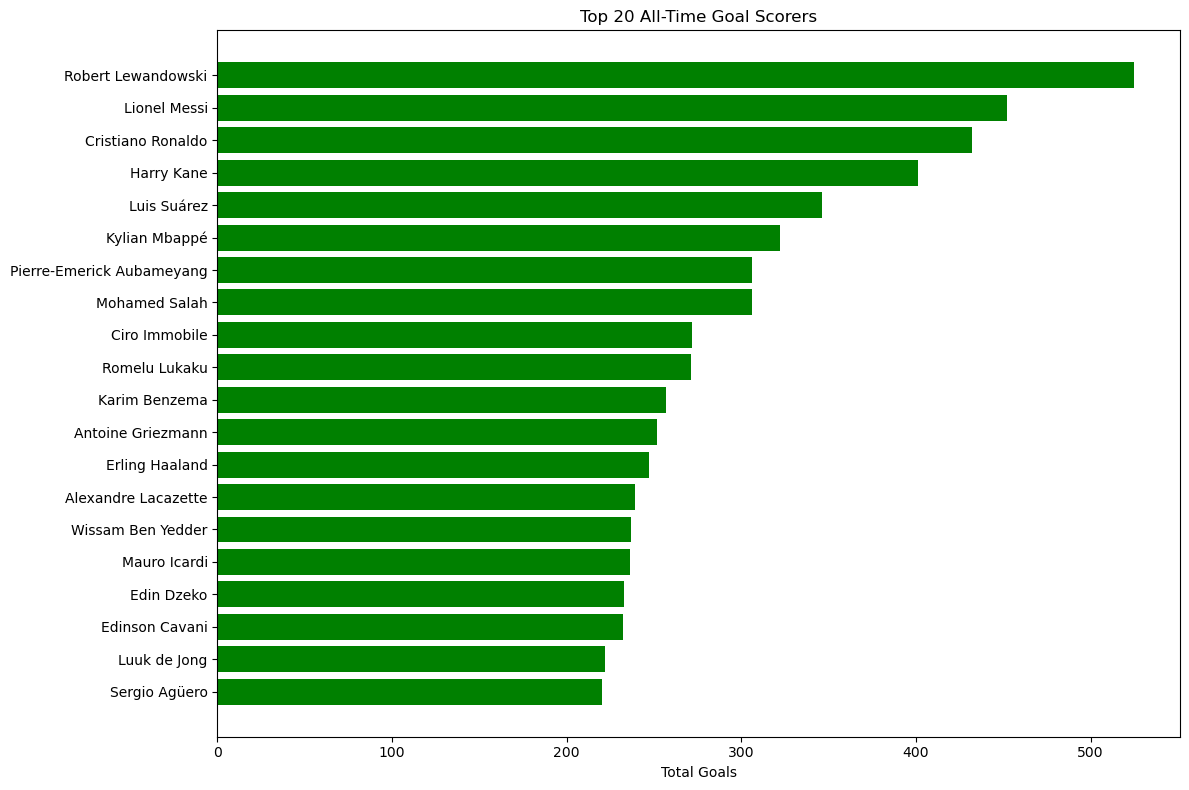

In [7]:
plt.figure(figsize=(12, 8))
plt.barh(top_scorers['player_name'], top_scorers['goals'], color='green')
plt.xlabel('Total Goals')
plt.title('Top 20 All-Time Goal Scorers')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

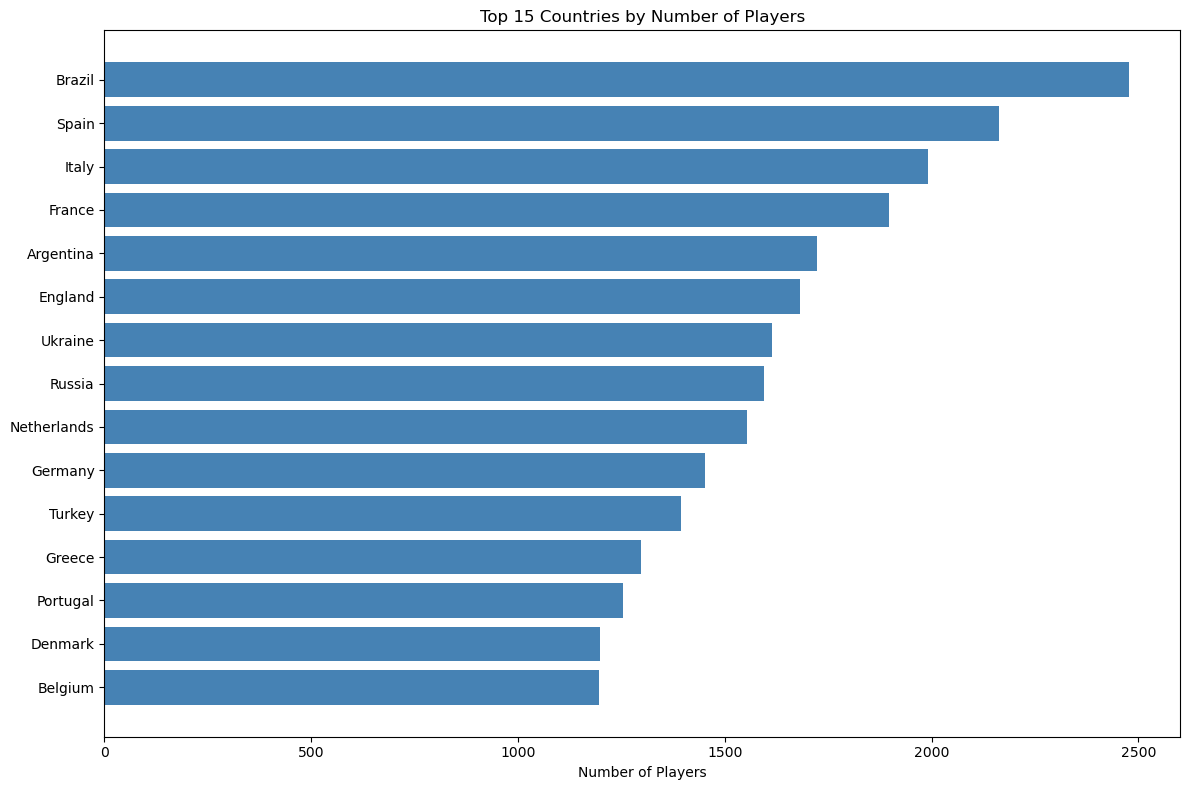

In [8]:
top_countries = players['country_of_citizenship'].value_counts().head(15)

plt.figure(figsize=(12, 8))
plt.barh(top_countries.index, top_countries.values, color='steelblue')
plt.xlabel('Number of Players')
plt.title('Top 15 Countries by Number of Players')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

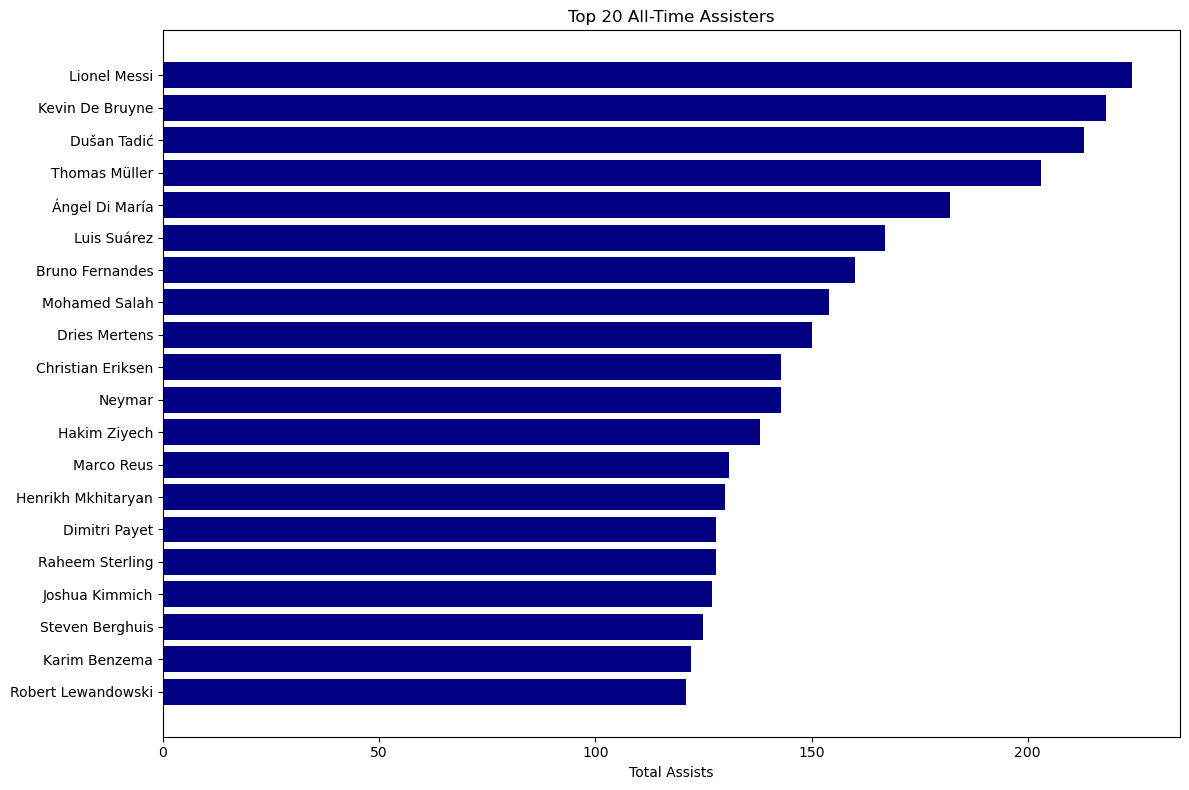

In [9]:
top_assisters = appearances.groupby('player_name')['assists'].sum().reset_index()
top_assisters = top_assisters.sort_values('assists', ascending=False).head(20)

plt.figure(figsize=(12, 8))
plt.barh(top_assisters['player_name'], top_assisters['assists'], color='navy')
plt.xlabel('Total Assists')
plt.title('Top 20 All-Time Assisters')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

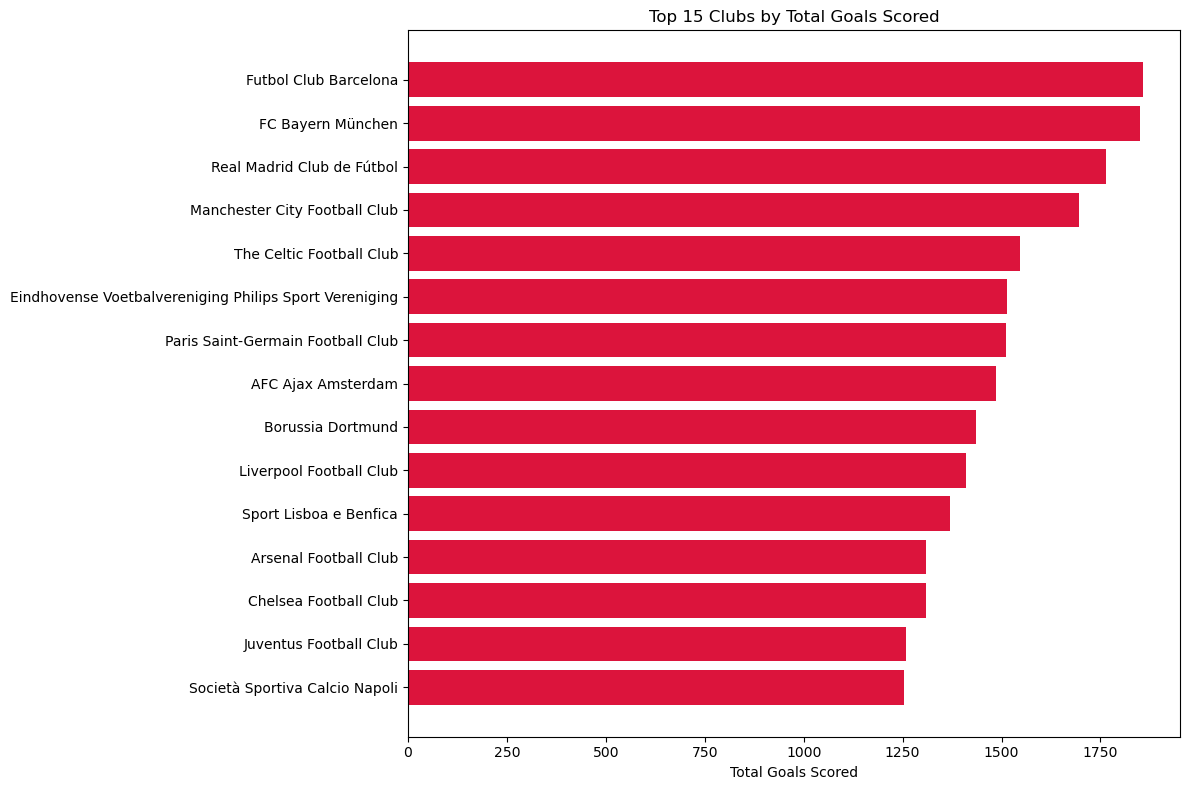

In [10]:
# Merge appearances with players to get club info
club_goals = appearances.groupby('player_club_id')['goals'].sum().reset_index()
clubs_renamed = clubs[['club_id', 'name']].rename(columns={'club_id': 'player_club_id'})
club_goals = club_goals.merge(clubs_renamed, on='player_club_id')
club_goals = club_goals.sort_values('goals', ascending=False).head(15)

plt.figure(figsize=(12, 8))
plt.barh(club_goals['name'], club_goals['goals'], color='crimson')
plt.xlabel('Total Goals Scored')
plt.title('Top 15 Clubs by Total Goals Scored')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()